In [153]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
df = pd.read_csv('dataset/review_shopee.csv')

df.head()

,content,score,label
0,Atakkarmita syahputra,1,negatif
1,untuk admin shopee saya mohon kebijaksanaanya ...,4,positif
2,cobak kalok pembohong jangan di masukan di sop...,1,negatif
3,iklan tai,1,negatif
4,2 kali beli barang lwat apps ini lebih dari 4 ...,1,negatif


In [155]:
df.isnull().sum()

content    0
score      0
label      0
dtype: int64

In [156]:
df.dropna(inplace=True)

In [157]:
df = df[df['label'] != 'netral']

In [158]:
X = df['content']
y = df['label']

In [159]:

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [160]:
print(type(y[0]))
print(y[:5])

<class 'numpy.int64'>
[0 1 0 0 0]


In [161]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [162]:
print(type(y_train[0]))
print(y_train[:5])

<class 'numpy.int64'>
[1 0 1 1 0]


In [163]:
tfidf = TfidfVectorizer(max_features=5000)

In [164]:
X_train = tfidf.fit_transform(X_train).toarray()

In [165]:
X_test = tfidf.transform(X_test).toarray()

In [166]:
model = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train.shape[1],)),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(2, activation='softmax')
])

/home/codespace/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [167]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [168]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10


W0000 00:00:1779561564.740447   11426 cpu_allocator_impl.cc:82] Allocation of 61560000 exceeds 10% of free system memory.


97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7664 - loss: 0.4712 - val_accuracy: 0.8286 - val_loss: 0.3322
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9243 - loss: 0.2058 - val_accuracy: 0.9052 - val_loss: 0.2583
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9695 - loss: 0.1009 - val_accuracy: 0.9052 - val_loss: 0.2747
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9860 - loss: 0.0603 - val_accuracy: 0.9078 - val_loss: 0.2922
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9912 - loss: 0.0405 - val_accuracy: 0.9039 - val_loss: 0.3283
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.0312 - val_accuracy: 0.9013 - val_loss: 0.3635
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9942 - loss: 0.0279 - val_accuracy: 0.9013 - val_loss: 0.3635
Epoch 8/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9945 - loss: 0.0237 - val_accuracy: 0.8987 - val_loss: 0.3941
Epo

In [169]:
print(type(y_train[0]))
print(y_train[:5])

<class 'numpy.int64'>
[1 0 1 1 0]


In [170]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

 1/31 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9062 - loss: 0.2369

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8785 - loss: 0.4535 
Loss : 0.4534800052642822
Accuracy : 0.8785046935081482


In [171]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [172]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73       222
           1       0.92      0.92      0.92       741

    accuracy                           0.88       963
   macro avg       0.83      0.83      0.83       963
weighted avg       0.88      0.88      0.88       963



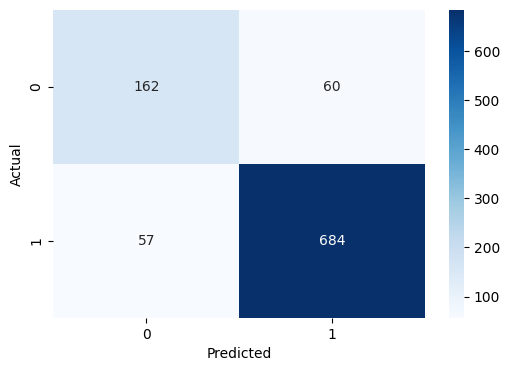

In [173]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [174]:
model.save('model/sentiment_model.h5')

In [175]:
with open('model/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [176]:
with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)